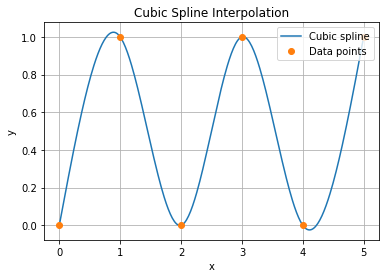

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)

h = np.diff(x)

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n - 2)
    B = np.zeros(n - 2)
    C = np.zeros(n - 2)
    D = np.zeros(n - 2)

    for i in range(1, n - 1):
        if i - 1 > 0:
            A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        if i - 1 < n - 3:
            C[i - 1] = h[i]
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    return A, B, C, D

def thomas_algorithm(A, B, C, D):
    n = len(B)

    c_prime = np.zeros(n)
    d_prime = np.zeros(n)

    c_prime[0] = C[0] / B[0]
    d_prime[0] = D[0] / B[0]

    for i in range(1, n):
        denom = B[i] - A[i] * c_prime[i - 1]
        c_prime[i] = C[i] / denom if i < n - 1 else 0
        d_prime[i] = (D[i] - A[i] * d_prime[i - 1]) / denom

    M_inner = np.zeros(n)
    M_inner[-1] = d_prime[-1]

    for i in range(n - 2, -1, -1):
        M_inner[i] = d_prime[i] - c_prime[i] * M_inner[i + 1]

    return M_inner

A, B, C, D = setup_tridiagonal_matrix(x, y)
M_inner = thomas_algorithm(A, B, C, D)

M = np.zeros(len(x))
M[1:-1] = M_inner

def evaluate_spline(x, y, M, x_eval):
    n = len(x)

    for i in range(n - 1):
        if x[i] <= x_eval <= x[i + 1]:
            h = x[i + 1] - x[i]

            term1 = M[i] * (x[i + 1] - x_eval)**3 / (6 * h)
            term2 = M[i + 1] * (x_eval - x[i])**3 / (6 * h)
            term3 = (y[i] - M[i] * h**2 / 6) * (x[i + 1] - x_eval) / h
            term4 = (y[i + 1] - M[i + 1] * h**2 / 6) * (x_eval - x[i]) / h

            return term1 + term2 + term3 + term4

    return None

x_spline = np.linspace(x[0], x[-1], 300)
y_spline = np.array([evaluate_spline(x, y, M, xi) for xi in x_spline])

plt.plot(x_spline, y_spline, label="Cubic spline")
plt.plot(x, y, "o", label="Data points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cubic Spline Interpolation")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Used ChatGPT for code structure and debugging
# Prompt used: "I understand the math for cubic spline interpolation, but can you help me structure the Python code for the tridiagonal system and Thomas algorithm?"